In [ ]:
# ── MLOps bootstrap (auto-injected by inject_mlops_cell.py) ──────────────────
import os, warnings, mlflow
warnings.filterwarnings("ignore")

SEED = 42
import random, numpy as np
random.seed(SEED)
np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass
try:
    import tensorflow as tf; tf.random.set_seed(SEED)
except ImportError:
    pass

_nb_name = os.path.basename(os.path.abspath("__file__") if "__file__" in dir() else ".").replace(".ipynb","")
mlflow.set_tracking_uri("sqlite:///" + str(Path(__file__).parent.parent.parent / "mlflow.db")
                        if "__file__" in dir() else "sqlite:///mlflow.db")
_exp = mlflow.set_experiment(_nb_name or "unnamed_notebook")
print(f"MLflow experiment: {_exp.name}")


#Spam Detection

In [ ]:
# --- Data Directory Setup (auto-generated) ---
from pathlib import Path
import os

# Resolve data directory relative to workspace root
def _find_data_dir():
    """Find the data directory by walking up from notebook location."""
    candidates = [
        Path.cwd().parent / "data" / "NLP Projecct 18.SMS spam detection",
        Path.cwd() / "data" / "NLP Projecct 18.SMS spam detection",
        Path(".").resolve().parent / "data" / "NLP Projecct 18.SMS spam detection",
    ]
    for c in candidates:
        if c.exists():
            return c
    # Fallback: current directory
    return Path(".")

DATA_DIR = _find_data_dir()
print(f"Data directory: {DATA_DIR}")

In [1]:
#Importing pandas and numoy library
import numpy as np 
import pandas as pd 
import nltk

In [52]:
#Loading and processing Datas
data = pd.read_csv(str(DATA_DIR / 'spam.csv'),encoding='latin-1')
data = data.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)
data = data.rename(columns={"v1":"label", "v2":"sms"})
data.head()

,label,sms
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [53]:
#Adding new column to the dataset for length of SMS
data['length'] = data['sms'].apply(len)
data.head()

,label,sms,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61


In [54]:
#Importing Matplotlib library.
import matplotlib.pyplot as plt
%matplotlib inline

array([<matplotlib.axes._subplots.AxesSubplot object at 0x7fa09107d510>,
      dtype=object)

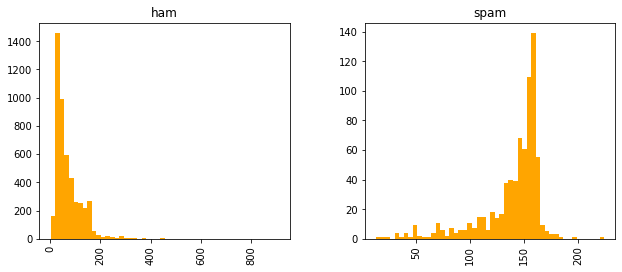

In [55]:
#Plotting the histogram
data.hist(column='length', by='label', bins=50,figsize=(10,4),color="orange")

In [56]:
data

,label,sms,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,161
5568,ham,Will Ì_ b going to esplanade fr home?,37
5569,ham,"Pity, * was in mood for that. So...any other s...",57
5570,ham,The guy did some bitching but I acted like i'd...,125


In [57]:
#labelling the Ham and Spam by 0 and 1
data.loc[:,'label'] = data.label.map({'ham':0, 'spam':1})
data.head()

,label,sms,length
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
#Importing Libraries
import string
import pprint
from collections import Counter
from collections import Counter

In [70]:
#Defining a function to return the frequency of words in documents
def frequency(documents):
    lower_case_documents = []
    lower_case_documents = [d.lower() for d in documents]
    sans_punctuation_documents = []
    for i in lower_case_documents:
        sans_punctuation_documents.append(i.translate(str.maketrans("","", string.punctuation))) 
    preprocessed_documents = [[w for w in d.split()] for d in sans_punctuation_documents]
    frequency_list = []
    frequency_list = [Counter(d) for d in preprocessed_documents]
    return lower_case_documents,preprocessed_documents,frequency_list

In [71]:
#The documents variable contains list of documents
documents = ['Hello, how are you!','Win money, win from home.','Call me now.','Hello, Call hello you tomorrow?']

In [74]:
#Extracting the data using the above function
lower_case_documents,preprocessed_documents,frequency_list=frequency(documents)
frequency_list

[Counter({'are': 1, 'hello': 1, 'how': 1, 'you': 1}),
 Counter({'from': 1, 'home': 1, 'money': 1, 'win': 2}),
 Counter({'call': 1, 'me': 1, 'now': 1}),
 Counter({'call': 1, 'hello': 2, 'tomorrow': 1, 'you': 1})]

In [79]:
#Importing countervectorizer module from sklearn library
from sklearn.feature_extraction.text import CountVectorizer
count_vec= CountVectorizer()

In [80]:
#Fitting the model to the vector
count_vec.fit(documents)
count_vec.get_feature_names()

['are',
 'call',
 'from',
 'hello',
 'home',
 'how',
 'me',
 'money',
 'now',
 'tomorrow',
 'win',
 'you']

In [81]:
#Converting the vector into array
doc_array = count_vec.transform(documents).toarray()
doc_array

array([[1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 2, 0],
       [0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0],
       [0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1]])

In [82]:
frequency_matrix = pd.DataFrame(doc_array, columns = count_vec.get_feature_names())
frequency_matrix

,are,call,from,hello,home,how,me,money,now,tomorrow,win,you
0,1,0,0,1,0,1,0,0,0,0,0,1
1,0,0,1,0,1,0,0,1,0,0,2,0
2,0,1,0,0,0,0,1,0,1,0,0,0
3,0,1,0,2,0,0,0,0,0,1,0,1


In [84]:
#Importing train test split from sklearn
from sklearn.model_selection import train_test_split

In [85]:
#Splitting the training and test dataset
X_train, X_test, y_train, y_test = train_test_split(data['sms'],data['label'],test_size=0.20,random_state=1)
# Fitting the training data and then return the matrix
training_data = count_vec.fit_transform(X_train)
# Transforming testing data and return the matrix. 
testing_data = count_vec.transform(X_test)

---
# Standardized ML Pipeline

**Step 1** — LazyPredict: automated baseline comparison of dozens of models  
**Step 2** — PyCaret: automated final pipeline (setup → compare → finalize)


In [ ]:
# ── STEP 1: LazyPredict — Baseline Model Comparison ──
from lazypredict.Supervised import LazyClassifier
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

_X_train = training_data.toarray() if hasattr(training_data, 'toarray') else np.array(training_data) if not isinstance(training_data, np.ndarray) else training_data
_X_test = testing_data.toarray() if hasattr(testing_data, 'toarray') else np.array(testing_data) if not isinstance(testing_data, np.ndarray) else testing_data
_y_train = np.array(y_train).ravel()
_y_test = np.array(y_test).ravel()

clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(_X_train, _X_test, _y_train, _y_test)
print(models)

# ── Metrics Extraction ──
best_model_name = models.sort_values('Accuracy', ascending=False).index[0]
_best_row = models.loc[best_model_name]
lp_accuracy = float(_best_row.get('Accuracy', 0))
lp_f1 = float(_best_row.get('F1 Score', 0))
print(f'\n>>> Best LazyPredict model: {best_model_name}')
print(f'    Accuracy={lp_accuracy:.4f}  F1={lp_f1:.4f}')


In [ ]:
# ── STEP 2: PyCaret — Final Pipeline ──
from pycaret.classification import setup, compare_models, finalize_model, pull

# Recombine train+test
_max_rows, _max_cols = 5000, 2000
_X_full = np.vstack([_X_train, _X_test])[:_max_rows, :min(_X_train.shape[1], _max_cols)]
_y_full = np.concatenate([_y_train, _y_test])[:_max_rows]

df_ml = pd.DataFrame(_X_full, columns=[f'f{i}' for i in range(_X_full.shape[1])])
df_ml['target'] = _y_full

s = setup(data=df_ml, target='target', session_id=42, verbose=False)
best = compare_models(n_select=1)
pycaret_results = pull()
print(pycaret_results)

final_model = finalize_model(best)
pycaret_model_name = type(best).__name__

# Extract PyCaret metrics
_pc_best = pycaret_results.iloc[0]
pc_accuracy = float(_pc_best.get('Accuracy', 0))
pc_precision = float(_pc_best.get('Prec.', 0))
pc_recall = float(_pc_best.get('Recall', 0))
pc_f1 = float(_pc_best.get('F1', 0))

print(f'\nPyCaret Best: {pycaret_model_name}')
print(f'  Accuracy={pc_accuracy:.4f}  Precision={pc_precision:.4f}  Recall={pc_recall:.4f}  F1={pc_f1:.4f}')


---
## Model Governance — Persistence & Registry

Save trained model, feature vectorizer, metrics, and register in global project registry.


In [ ]:
import json, os
from datetime import datetime
from pathlib import Path
from joblib import dump

project_name = 'sms_spam_detection'
_artifacts_dir = Path('..') / 'artifacts' / project_name
_artifacts_dir.mkdir(parents=True, exist_ok=True)

# Save trained model
dump(final_model, str(_artifacts_dir / 'model.joblib'))

# Save feature vectorizer
dump(count_vec, str(_artifacts_dir / 'vectorizer.joblib'))

# Save metrics
_metrics = {
    'best_model_lazypredict': best_model_name,
    'pycaret_model': pycaret_model_name,
    'accuracy': pc_accuracy,
    'f1': pc_f1,
    'precision': pc_precision,
    'recall': pc_recall,
    'lp_accuracy': lp_accuracy,
    'lp_f1': lp_f1,
}
with open(str(_artifacts_dir / 'metrics.json'), 'w') as f:
    json.dump(_metrics, f, indent=2)

# Update global registry
_registry_path = Path('..') / 'artifacts' / 'global_registry.json'
_registry_path.parent.mkdir(parents=True, exist_ok=True)
if _registry_path.exists():
    with open(str(_registry_path)) as f:
        _registry = json.load(f)
else:
    _registry = []
_registry = [e for e in _registry if e.get('project') != project_name]
_registry.append({
    'project': project_name,
    'best_model': best_model_name,
    'pycaret_model': pycaret_model_name,
    'accuracy': pc_accuracy,
    'timestamp': datetime.now().isoformat(),
})
with open(str(_registry_path), 'w') as f:
    json.dump(_registry, f, indent=2)

print(f'Artifacts saved to {_artifacts_dir}/')


In [ ]:
# ── Inference Function ──
def predict_text(text):
    """Run inference on a single text input."""
    vec = count_vec.transform([text])
    return final_model.predict(vec)

print('Inference function ready: predict_text(text)')


In [ ]:
# ── Consistency Checks ──
assert final_model is not None, 'Final model was not created'
assert best_model_name is not None, 'Best model name was not captured'
assert (_artifacts_dir / 'model.joblib').exists(), 'Model file not saved'
assert (_artifacts_dir / 'metrics.json').exists(), 'Metrics file not saved'

# ── Summary ──
print('=' * 50)
print('MODEL GOVERNANCE SUMMARY')
print('=' * 50)
print(f'Project:              {project_name}')
print(f'Best Model (LP):      {best_model_name}')
print(f'Best Model (PyCaret): {pycaret_model_name}')
print(f'Accuracy:             {pc_accuracy:.4f}')
print(f'Precision:            {pc_precision:.4f}')
print(f'Recall:               {pc_recall:.4f}')
print(f'F1 Score:             {pc_f1:.4f}')
print(f'Artifacts:            {_artifacts_dir}/')
print('=' * 50)
